# Recommender Training (MovieLens)

Train the baseline MovieLens recommender model and inspect metrics. Artifacts are saved under models/recommender/.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
for cand in [repo_root, *repo_root.parents]:
    if (cand / 'app').exists():
        repo_root = cand
        break
sys.path.insert(0, str(repo_root))
print('Repo root:', repo_root)


Repo root: /Users/pratik_n/Desktop/MyComputer/universal-anomaly-intelligence-v2


## Data requirements

Place data/raw/recommendation/movielens.csv with columns userId,movieId,rating. For faster experiments, use --sample-size to subsample rows.


In [2]:
# Update paths if your data lives elsewhere.



In [3]:
data_path = repo_root / 'data' / 'raw' / 'recommendation' / 'movielens.csv'
print('Movielens exists:', data_path.exists(), data_path)


Movielens exists: True /Users/pratik_n/Desktop/MyComputer/universal-anomaly-intelligence-v2/data/raw/recommendation/movielens.csv


## Train the recommender


In [4]:
# !python -m src.train.train_movielens_recommender --sample-size 200000


## Review saved metrics


In [5]:
metrics_path = repo_root / 'experiments' / 'recommender' / 'metrics' / 'movielens_metrics.json'
if metrics_path.exists():
    print(metrics_path.read_text(encoding='utf-8')[:1000])
else:
    print('Metrics not found yet.')


{
  "0": {
    "precision": 0.734118009868421,
    "recall": 0.7064147583955686,
    "f1-score": 0.72,
    "support": 20219.0
  },
  "1": {
    "precision": 0.7110591900311527,
    "recall": 0.7384864263687376,
    "f1-score": 0.724513329200248,
    "support": 19781.0
  },
  "accuracy": 0.722275,
  "macro avg": {
    "precision": 0.7225885999497869,
    "recall": 0.7224505923821531,
    "f1-score": 0.722256664600124,
    "support": 40000.0
  },
  "weighted avg": {
    "precision": 0.7227148469883959,
    "recall": 0.722275,
    "f1-score": 0.7222319541227528,
    "support": 40000.0
  }
}


## Visuals and metrics


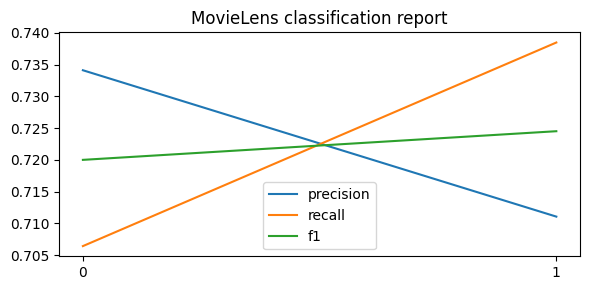

In [6]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = repo_root / 'experiments' / 'recommender' / 'metrics' / 'movielens_metrics.json'
if not metrics_path.exists():
    print('Metrics not found:', metrics_path)
else:
    report = json.loads(metrics_path.read_text(encoding='utf-8'))
    labels = [k for k in report.keys() if k.isdigit()]
    if not labels:
        print('No class labels in report')
    else:
        precisions = [report[l]['precision'] for l in labels]
        recalls = [report[l]['recall'] for l in labels]
        f1s = [report[l]['f1-score'] for l in labels]
        x = range(len(labels))
        plt.figure(figsize=(6, 3))
        plt.plot(x, precisions, label='precision')
        plt.plot(x, recalls, label='recall')
        plt.plot(x, f1s, label='f1')
        plt.xticks(x, labels)
        plt.title('MovieLens classification report')
        plt.legend()
        plt.tight_layout()
        plt.show()
